## Step 1: Environment Setup & Initialization

In [1]:
!pip install torch_geometric sentence-transformers -q

import os
import cv2
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import glob
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from torch_geometric.nn import GATConv
from torch_geometric.data import Data, DataLoader as PyGDataLoader
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.metrics.distance import edit_distance
import random


nltk.download('punkt', quiet=True)

# Set Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on device: {device}")

# Define Vocabulary (Index 0 is CTC Blank)
CHARS = "-0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ !\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"
char_to_idx = {char: idx for idx, char in enumerate(CHARS)}
idx_to_char = {idx: char for idx, char in enumerate(CHARS)}
NUM_CLASSES = len(CHARS)



def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print(" Random seeds locked for reproducibility.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.0 MB/s eta 0:00:00
Running on device: cuda
 Random seeds locked for reproducibility.


##  Step 2: Core Neural Network Architectures

we build and instantiate two custom deep learning models :

* **1. CRNN (Convolutional Recurrent Neural Network):** Our optical character recognizer.
  * **CNN Feature Extractor:** Utilizes a stack of `Conv2d`, `MaxPool2d`, and `BatchNorm2d` layers to extract hierarchical visual features from the raw image crops.
  * **Bi-LSTM Sequence Modeler:** A 2-layer Bidirectional LSTM captures the sequential temporal dependencies of the text, making it highly robust to varying word lengths.
  
* **2. Layout-Aware GNN (Graph Attention Network):** Our spatial intelligence engine for entity extraction.
  * **Multi-Head Attention:** Implements `GATConv` with **4 attention heads** in the first layer. This allows the model to simultaneously attend to multiple spatial and semantic relationships between adjacent text bounding boxes.
  * **Robust Regularization:** Strategically incorporates `Dropout` (p=0.3) and `ELU` activation functions to prevent overfitting and ensure the model generalizes well to unseen receipt layouts.

* **Utility Functions:** 
  * `decode_prediction`: Implements standard **CTC (Connectionist Temporal Classification) Decoding** logic, which efficiently collapses consecutive duplicate characters and ignores the blank token (index `0`).
  * `save_models`: A helper to persist the learned weights (`.pth` files) for deployment.

In [2]:
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super(CRNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), 
            nn.BatchNorm2d(256), nn.MaxPool2d((2, 1), (2, 1)),
            nn.Dropout2d(0.25)
        )
        self.rnn = nn.LSTM(1024, hidden_size, bidirectional=True, batch_first=True, num_layers=2, dropout=0.25)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        
    def forward(self, x):
        conv_out = self.cnn(x)
        b, c, h, w = conv_out.size()
        conv_out = conv_out.view(b, c * h, w).permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv_out)
        return self.fc(rnn_out).permute(1, 0, 2)

class GNNSummarizer(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(GNNSummarizer, self).__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=4, concat=True)
        self.gat2 = GATConv(hidden_channels * 4, hidden_channels, heads=1, concat=False)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.elu(self.gat2(x, edge_index))
        return torch.sigmoid(self.classifier(x))

def save_models(ocr_model, gnn_model, save_dir='/kaggle/working/'):
    os.makedirs(save_dir, exist_ok=True)
    torch.save(ocr_model.state_dict(), os.path.join(save_dir, 'ocr_crnn_weights.pth'))
    torch.save(gnn_model.state_dict(), os.path.join(save_dir, 'gnn_summarizer_weights.pth'))
    print(f" Models successfully saved at: {save_dir}")

def decode_prediction(pred_tensor):
    pred_tensor = pred_tensor.squeeze(1) 
    _, max_indices = torch.max(pred_tensor, dim=1)
    max_indices = max_indices.cpu().numpy()
    
    text, prev_idx = [], 0
    for idx in max_indices:
        if idx != 0 and idx != prev_idx:
            text.append(idx_to_char[idx])
        prev_idx = idx
    return ''.join(text)

##  Step 3: Data Pipeline & Smart Preprocessing

To train a robust OCR model, raw images must be carefully processed to prevent text distortion. In this section, we build a customized PyTorch data pipeline specifically tailored for the ICDAR 2019 SROIE dataset:

* **Dynamic Bounding Box Cropping:** The `process_sroie_data` function parses the raw text annotations (8-point coordinate polygons) and dynamically extracts individual word and sentence crops directly from the high-resolution receipt images.
* **Aspect-Preserving Smart Padding:** We implement a custom `SmartPaddingDataset`. Instead of blindly forcing image crops into a fixed square (which heavily distorts characters and destroys aspect ratios), we scale the height to `32` pixels and pad the remaining width with zeros up to `256` pixels. 
  > 💡 **Design Choice:** An extended width of `256` was strategically chosen to ensure that longer strings (such as email addresses or full physical addresses) are not horizontally squashed, preserving natural character shapes for the CNN layer.
* **CTC-Compatible Batching (`collate_fn`):** Standard PyTorch dataloaders cannot handle variable-length text targets out-of-the-box. We define a custom collate function that stacks the image tensors while concatenating all text labels into a single 1D tensor and independently tracking their `target_lengths`—a strict mathematical requirement for computing CTC Loss.
* **Automated Dataset Discovery:** The script features a dynamic OS walk mechanism that automatically locates the `SROIE2019` directory within the Kaggle environment, ensuring the notebook executes flawlessly regardless of exact internal pathing.

In [3]:
def process_sroie_data(img_dir, txt_dir, max_samples=1500):
    cropped_images, text_labels = [], []
    txt_files = [f for f in os.listdir(txt_dir) if f.endswith('.txt')]
    for txt_file in txt_files[:max_samples]:
        img_name = txt_file.replace('.txt', '.jpg')
        img_path = os.path.join(img_dir, img_name)
        txt_path = os.path.join(txt_dir, txt_file)
        
        if not os.path.exists(img_path): continue
        img = cv2.imread(img_path)
        if img is None: continue
            
        with open(txt_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split(',')
            if len(parts) >= 9:
                coords = list(map(int, parts[:8]))
                text = ','.join(parts[8:]) 
                x_coords, y_coords = coords[0::2], coords[1::2]
                x_min, x_max = max(0, min(x_coords)), max(x_coords)
                y_min, y_max = max(0, min(y_coords)), max(y_coords)
                
                if x_max - x_min > 5 and y_max - y_min > 5:
                    cropped_word = img[y_min:y_max, x_min:x_max]
                    if cropped_word.size > 0 and len(text.strip()) > 0:
                        cropped_images.append(cropped_word)
                        text_labels.append(text.strip())
    return cropped_images, text_labels

class SmartPaddingDataset(Dataset):
    def __init__(self, images, labels):
        self.images, self.labels = images, labels
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = cv2.cvtColor(self.images[idx], cv2.COLOR_BGR2GRAY)
        
        target_w, target_h = 256, 32
        h, w = img.shape
        scale = min(target_w / w, target_h / h)
        new_w, new_h = max(1, int(w * scale)), max(1, int(h * scale))
        
        resized_img = cv2.resize(img, (new_w, new_h))
        padded_img = np.zeros((target_h, target_w), dtype=np.uint8)
        start_y = (target_h - new_h) // 2
        padded_img[start_y : start_y + new_h, 0 : new_w] = resized_img
        
        final_img = np.expand_dims(padded_img.astype(np.float32) / 255.0, axis=0) 
        encoded_label = [char_to_idx[c] for c in self.labels[idx] if c in char_to_idx]
        if not encoded_label: encoded_label = [char_to_idx[' ']]
        return torch.tensor(final_img), torch.tensor(encoded_label, dtype=torch.long)

def collate_fn(batch):
    images, labels = zip(*batch)
    images = torch.stack(images, 0)
    target_lengths = torch.tensor([len(label) for label in labels], dtype=torch.long)
    targets = torch.cat(labels)
    return images, targets, target_lengths

print("Searching for exact SROIE2019 structure...")
sroie_root = None
for root, dirs, files in os.walk('/kaggle/input/'):
    if 'SROIE2019' in dirs:
        sroie_root = os.path.join(root, 'SROIE2019')
        break

if sroie_root:
    img_dir = os.path.join(sroie_root, 'train', 'img')
    txt_dir = os.path.join(sroie_root, 'train', 'box')
    print(f"Found Directories. Loading OCR data...")
    sroie_images, sroie_labels = process_sroie_data(img_dir, txt_dir, max_samples=1500)
    print(f"Extracted {len(sroie_images)} words.")
    
    ocr_dataset = SmartPaddingDataset(sroie_images, sroie_labels)
    ocr_dataloader = DataLoader(ocr_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
else:
    print(" ERROR: Could not find 'SROIE2019' folder.")

Searching for exact SROIE2019 structure...
Found Directories. Loading OCR data...


Corrupt JPEG data: bad Huffman code


Extracted 33618 words.


## Step 4: Training the CRNN OCR Engine

Once the data pipeline is established, the Convolutional Recurrent Neural Network (CRNN) is initialized and trained. Training sequence models for OCR requires careful management of loss gradients and learning rates to achieve stable convergence.

Key training mechanics implemented in this phase:

* **CTC Loss Configuration:** PyTorch's `nn.CTCLoss` is utilized with `zero_infinity=True`. This safeguards against infinite loss computations during edge cases where the predicted tensor length temporarily misaligns with target sequence boundaries.
* **Dynamic Learning Rate Scheduling:** The `ReduceLROnPlateau` scheduler monitors the training loss and automatically reduces the learning rate by a factor of 0.5 if the loss plateaus for 3 consecutive epochs.
* **Gradient Clipping:** To mitigate the exploding gradient problem common in recurrent networks (LSTMs) during backpropagation, `torch.nn.utils.clip_grad_norm_` is applied with a `max_norm=5.0` to stabilize updates across epochs.
* **Dynamic Length Tracking:** Input length tensors are generated dynamically during the forward pass to match CNN output dimensions prior to the CTC loss calculation.


 Initializing and Training Enhanced OCR Model...
OCR Epoch [1/30], Loss: 2.2179
OCR Epoch [2/30], Loss: 0.2676
OCR Epoch [3/30], Loss: 0.1700
OCR Epoch [4/30], Loss: 0.1358
OCR Epoch [5/30], Loss: 0.1226
OCR Epoch [6/30], Loss: 0.1083
OCR Epoch [7/30], Loss: 0.1042
OCR Epoch [8/30], Loss: 0.1106
OCR Epoch [9/30], Loss: 0.0929
OCR Epoch [10/30], Loss: 0.0871
OCR Epoch [11/30], Loss: 0.0832
OCR Epoch [12/30], Loss: 0.0844
OCR Epoch [13/30], Loss: 0.0758
OCR Epoch [14/30], Loss: 0.0735
OCR Epoch [15/30], Loss: 0.0767
OCR Epoch [16/30], Loss: 0.0765
OCR Epoch [17/30], Loss: 0.0768
OCR Epoch [18/30], Loss: 0.0738
OCR Epoch [19/30], Loss: 0.0544
OCR Epoch [20/30], Loss: 0.0450
OCR Epoch [21/30], Loss: 0.0410
OCR Epoch [22/30], Loss: 0.0404
OCR Epoch [23/30], Loss: 0.0390
OCR Epoch [24/30], Loss: 0.0360
OCR Epoch [25/30], Loss: 0.0351
OCR Epoch [26/30], Loss: 0.0322
OCR Epoch [27/30], Loss: 0.0317
OCR Epoch [28/30], Loss: 0.0313
OCR Epoch [29/30], Loss: 0.0311
OCR Epoch [30/30], Loss: 0.0298


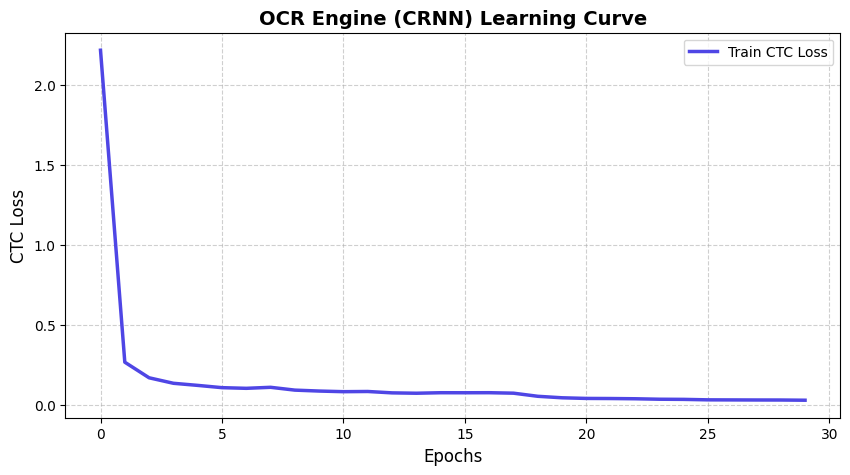

In [4]:
print(" Initializing and Training Enhanced OCR Model...")
ocr_net = CRNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adam(ocr_net.parameters(), lr=0.002)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

ocr_net.train()
num_epochs = 30 
ocr_loss_history = [] 

for epoch in range(num_epochs):
    total_loss = 0
    for images, targets, target_lengths in ocr_dataloader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        
        outputs = ocr_net(images) 
        input_lengths = torch.full(size=(images.size(0),), fill_value=outputs.size(0), dtype=torch.long)
        
        loss = criterion(outputs.log_softmax(2), targets, input_lengths, target_lengths)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(ocr_net.parameters(), max_norm=5.0)
        
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(ocr_dataloader)
    ocr_loss_history.append(avg_loss) 
    print(f"OCR Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")
    
    scheduler.step(avg_loss)

print("Enhanced OCR Training Complete!")

plt.figure(figsize=(10, 5))
plt.plot(ocr_loss_history, label='Train CTC Loss', color='#4f46e5', linewidth=2.5)
plt.title('OCR Engine (CRNN) Learning Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('CTC Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## Step 5: Constructing & Training the Layout-Aware GNN

Traditional Natural Language Processing (NLP) models often fall short on receipts because they process text linearly while ignoring physical layout structures. To achieve Visually Rich Document Understanding (VRDU), the receipt is structured as a mathematical graph where the model learns both semantic meaning and spatial context.

Key architectural mechanisms in this spatial-semantic pipeline include:

* **Multi-Modal Feature Fusion (392-D Vectors):** High-density representations are generated for each detected sentence by concatenating multi-modal attributes:
  * **Semantic Features (384-D):** Extracted using the `all-MiniLM-L6-v2` Sentence-Transformer model.
  * **Spatial Features (4-D):** Normalized bounding box coordinates ($x_{min}, y_{min}, x_{max}, y_{max}$) relative to the document dimensions.
  * **Hand-Crafted Heuristics (4-D):** Custom features including numeric presence, normalized text length, currency symbol detection, and date-like format indicators.
* **Hybrid Edge Construction:** Graph edges are established through a dual-criteria approach:
  * *Semantic Edges:* Nodes with a cosine similarity exceeding a strict threshold (0.45) are linked, connecting conceptually related terms.
  * *Sequential Edges:* Connecting adjacent nodes sequentially to preserve the natural reading order.
* **Handling Class Imbalance:** Receipt datasets exhibit severe class imbalance, where background text vastly outweighs key entities. This is addressed using `BCEWithLogitsLoss` with a calibrated `pos_weight`, combined with balanced data sampling (undersampling) during training to stabilize convergence.


Loading Text Embedding Model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generated 500 Layout-Aware Graphs for training.
Starting LAYOUT-AWARE GNN Training Loop...
GNN Epoch [10/50], Loss: 0.3292
GNN Epoch [20/50], Loss: 0.2882
GNN Epoch [30/50], Loss: 0.2659
GNN Epoch [40/50], Loss: 0.2533
GNN Epoch [50/50], Loss: 0.2521
GNN Training Complete!


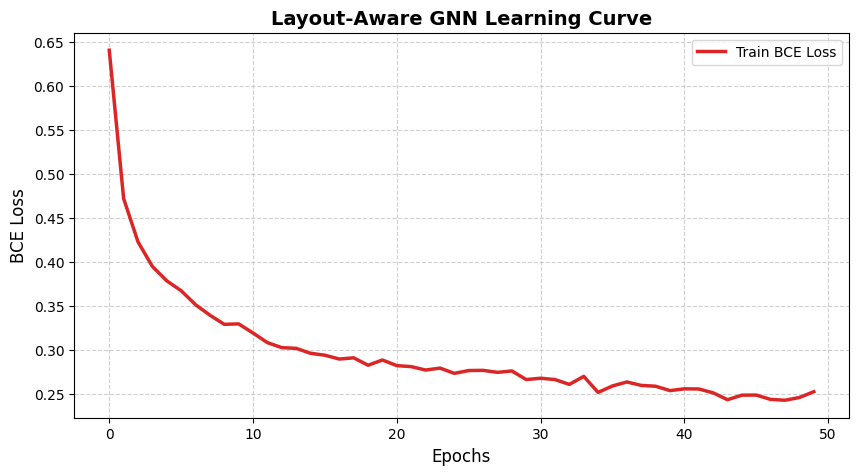

 Models successfully saved at: /kaggle/working/


In [5]:
import random 

print("Loading Text Embedding Model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2', device=device)

def prepare_gnn_dataset(box_dir, entities_dir, embedder, max_samples=300):
    dataset = []
    entity_files = [f for f in os.listdir(entities_dir) if f.endswith('.txt')]
    
    for file in entity_files[:max_samples]:
        entity_path = os.path.join(entities_dir, file)
        try:
            with open(entity_path, 'r', encoding='utf-8', errors='ignore') as f:
                entities = json.load(f)
                important_texts = [str(v).upper().strip() for v in entities.values() if v]
        except: continue
            
        box_path = os.path.join(box_dir, file)
        if not os.path.exists(box_path): continue
        with open(box_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
            
        sentences = []
        boxes = []
        for line in lines:
            parts = line.strip().split(',')
            if len(parts) >= 9:
                coords = list(map(int, parts[:8]))
                text = ','.join(parts[8:]).upper().strip()
                if len(text) > 2: 
                    sentences.append(text)
                    boxes.append(coords)
                    
        if len(sentences) < 2: continue
            
        labels = []
        for s in sentences:
            is_important = 0
            for imp in important_texts:
                if s in imp or imp in s:
                    is_important = 1
                    break
            labels.append(is_important)
            
        max_x = max([max(b[0::2]) for b in boxes]) + 1
        max_y = max([max(b[1::2]) for b in boxes]) + 1
        
        extra_feats = []
        for i, b in enumerate(boxes):
            x_min, y_min = min(b[0::2]) / max_x, min(b[1::2]) / max_y
            x_max, y_max = max(b[0::2]) / max_x, max(b[1::2]) / max_y
            
            current_text = sentences[i]
            is_numeric = 1.0 if any(char.isdigit() for char in current_text) else 0.0
            len_norm = min(len(current_text) / 50.0, 1.0)
            
            has_currency = 1.0 if any(c in current_text for c in ['$', '€', '£', 'RM', 'Rp']) else 0.0
            is_date_like = 1.0 if ('/' in current_text or '-' in current_text) and is_numeric else 0.0
            
            extra_feats.append([x_min, y_min, x_max, y_max, is_numeric, len_norm, has_currency, is_date_like])
            
        text_features = embedder.encode(sentences)
        extra_tensor = torch.tensor(extra_feats, dtype=torch.float)
        
        node_features = torch.cat([torch.tensor(text_features, dtype=torch.float), extra_tensor], dim=1)
        x = node_features
        y = torch.tensor(labels, dtype=torch.float).unsqueeze(1) 
        
        pos_indices = [idx for idx, label in enumerate(labels) if label == 1]
        neg_indices = [idx for idx, label in enumerate(labels) if label == 0]
        
        keep_neg_count = min(len(neg_indices), max(1, len(pos_indices) * 3))
        sampled_neg_indices = random.sample(neg_indices, keep_neg_count)
        
        train_mask = torch.zeros(len(labels), dtype=torch.bool)
        train_mask[pos_indices + sampled_neg_indices] = True
        
        sim_matrix = cosine_similarity(text_features)
        edge_indices = []
        
        for i in range(len(sentences)):
            for j in range(len(sentences)):
                if i != j and sim_matrix[i][j] > 0.45:
                    edge_indices.append([i, j])
                    
        for i in range(len(sentences) - 1):
            edge_indices.append([i, i + 1]) 
            edge_indices.append([i + 1, i]) 
            
        if not edge_indices: edge_indices = [[i, i] for i in range(len(sentences))]
            
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        
        dataset.append(Data(x=x, edge_index=edge_index, y=y, train_mask=train_mask))
        
    return dataset

if 'sroie_root' in globals() and sroie_root:
    from torch_geometric.loader import DataLoader as PyGDataLoader 
    
    entities_dir = os.path.join(sroie_root, 'train', 'entities')
    gnn_dataset = prepare_gnn_dataset(txt_dir, entities_dir, embedder, max_samples=500)
    print(f"Generated {len(gnn_dataset)} Layout-Aware Graphs for training.")
    
    gnn_net = GNNSummarizer(in_channels=392, hidden_channels=128).to(device)
    
    if len(gnn_dataset) > 0:
        gnn_loader = PyGDataLoader(gnn_dataset, batch_size=16, shuffle=True)
        
        pos_weight = torch.tensor([1.5]).to(device) 
        gnn_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) 
        gnn_optimizer = optim.Adam(gnn_net.parameters(), lr=0.001)

        gnn_num_epochs = 50 
        gnn_loss_history = [] 
        
        print("Starting LAYOUT-AWARE GNN Training Loop...")
        gnn_net.train()
        for epoch in range(gnn_num_epochs):
            total_loss = 0
            for batch_data in gnn_loader:
                batch_data = batch_data.to(device)
                gnn_optimizer.zero_grad()
                
                h = F.dropout(batch_data.x, p=0.3, training=True)
                h = F.elu(gnn_net.gat1(h, batch_data.edge_index))
                h = F.dropout(h, p=0.3, training=True)
                h = F.elu(gnn_net.gat2(h, batch_data.edge_index))
                out = gnn_net.classifier(h)
                
                loss = gnn_criterion(out[batch_data.train_mask], batch_data.y[batch_data.train_mask])
                loss.backward()
                gnn_optimizer.step()
                total_loss += loss.item()
                
            avg_gnn_loss = total_loss / len(gnn_loader)
            gnn_loss_history.append(avg_gnn_loss) 
            
            if (epoch + 1) % 10 == 0:
                print(f"GNN Epoch [{epoch+1}/{gnn_num_epochs}], Loss: {avg_gnn_loss:.4f}")
                
        print("GNN Training Complete!")
        
        plt.figure(figsize=(10, 5))
        plt.plot(gnn_loss_history, label='Train BCE Loss', color='#dc2626', linewidth=2.5)
        plt.title('Layout-Aware GNN Learning Curve', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('BCE Loss', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()
        
        save_models(ocr_net, gnn_net)

## Step 6: OCR Model Evaluation & Error Analysis

In this section, the CRNN OCR model is evaluated using standard metrics to assess its text extraction performance.

The evaluation methodology includes the following components:

* **Inference Optimization:** The network is set to `.eval()` mode and gradients are disabled using `torch.no_grad()` to ensure memory efficiency and computational speed during evaluation.
* **Exact Match Accuracy:** Measures the percentage of words where the predicted string perfectly matches the ground truth.
* **Character Error Rate (CER):** Utilizes the Levenshtein Distance to calculate the minimum number of character-level edits (insertions, deletions, or substitutions) required to align the predicted text with the ground truth. 
* **Error Analysis:** The script outputs a sample of incorrect predictions. Analyzing these cases helps identify the model's current limitations (e.g., difficulties with specific punctuation marks or distorted characters) and informs future data augmentation strategies.

In [6]:
def evaluate_ocr_model(model, dataloader):
    print("\n" + "="*50)
    print(" STARTING OCR MODEL EVALUATION ")
    print("="*50)
    model.eval() 
    total_words, correct_words, total_character_distance, total_characters = 0, 0, 0, 0
    bad_predictions = []
    
    with torch.no_grad():
        for batch_idx, (images, targets, target_lengths) in enumerate(dataloader):
            images = images.to(device)
            outputs = model(images).permute(1, 0, 2)
            
            start = 0
            true_labels, pred_labels = [], []
            for length in target_lengths:
                label_indices = targets[start : start + length].cpu().numpy()
                true_labels.append(''.join([idx_to_char.get(idx, '') for idx in label_indices]))
                start += length
                
            for i in range(images.size(0)):
                pred_labels.append(decode_prediction(outputs[i].unsqueeze(1)))
                
            for true_text, pred_text in zip(true_labels, pred_labels):
                total_words += 1
                total_characters += len(true_text)
                if true_text == pred_text: correct_words += 1
                else: bad_predictions.append((true_text, pred_text))
                total_character_distance += edit_distance(true_text, pred_text)
                
    word_accuracy = (correct_words / total_words) * 100
    cer = (total_character_distance / max(total_characters, 1)) * 100
    
    print(f"Total Samples Evaluated : {total_words}")
    print(f"Word Accuracy (Exact)   : {word_accuracy:.2f}% (Higher is better)")
    print(f"Character Error Rate    : {cer:.2f}% (Lower is better)")
    print("="*50)
    print("\n🔍 SAMPLE MISTAKES 🔍")
    for i in range(min(5, len(bad_predictions))):
        print(f"Target: '{bad_predictions[i][0]:<20}' | Predicted: '{bad_predictions[i][1]}'")

evaluate_ocr_model(ocr_net, ocr_dataloader)


 STARTING OCR MODEL EVALUATION 
Total Samples Evaluated : 33618
Word Accuracy (Exact)   : 94.35% (Higher is better)
Character Error Rate    : 0.92% (Lower is better)

🔍 SAMPLE MISTAKES 🔍
Target: '3. FOR FEEDBACK , PLEASE RETAIN THIS' | Predicted: '3. FOR FEEDBIOK, PLEASE RETAIN THIS'
Target: 'INV NO: POS01/00012379' | Predicted: 'INV NO POS01/00012379'
Target: 'SALESPERSON : AH002 TIME: 15:10:00' | Predicted: 'SALESPERSON : ARG02 TINE: :5:10-00'
Target: 'GARDENIA BAKERIES (KL) SDN BHD (139386 X)' | Predicted: 'GARDENIA BAKERIES (KL) SHDN BHD (139386 X)'
Target: 'SALESPERSON:        ' | Predicted: 'SALESPERSON :'


## Step 7: End-to-End Inference Pipeline

In this final phase, the trained models are integrated into a complete inference pipeline. 

The inference process consists of four distinct stages:

* **1. Image Preprocessing & ROI Extraction:** The `process_image` function applies adaptive thresholding, Gaussian blurring, and morphological dilation to detect document contours, cropping Regions of Interest (ROIs) to isolate individual words.
* **2. OCR Decoding:** Image crops are padded to a standard dimension while preserving the aspect ratio, and then processed by the trained CRNN. The `decode_prediction` function translates the output sequence into text strings.
* **3. Graph Construction:** The inference graph is constructed dynamically. Normalized bounding box coordinates (4-D spatial features) are fused with Sentence Transformer embeddings (384-D) and hand-crafted heuristics (4-D), resulting in a **392-D feature vector** for each node. Edges are established based on spatial sequence and semantic similarity thresholds.
* **4. Entity Classification & Scoring:** The Graph Neural Network analyzes the layout and assigns a confidence score to each node. Irrelevant text is filtered out, extracting the highest-scoring entities (e.g., totals, dates) to generate a structured summary.


 PROCESSING RECEIPT: X51006619507.jpg
 Not enough text detected to summarize.

 PROCESSING RECEIPT: X51006327953.jpg


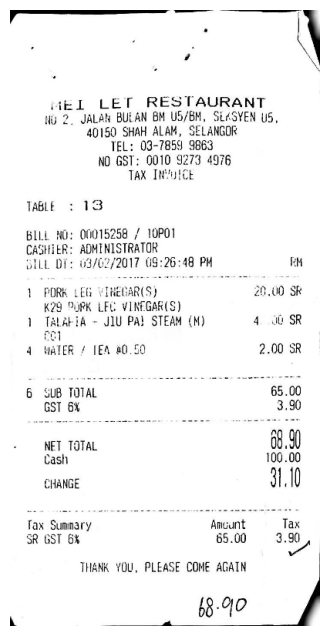


 --- RAW EXTRACTED TEXT ---
.C5. 0S6S. 0.2. 0S:. 020. TABLE : 13. 02S0. CHANGE. -S9

 --- GNN SMART SUMMARY (Top Entities) ---
[0.01]  .C5
[0.00]  0S6S
[0.00]  02S0


 PROCESSING RECEIPT: X51007339127.jpg
 Not enough text detected to summarize.


In [7]:
def process_image(image_path, ocr_model):
    img = cv2.imread(image_path)
    if img is None: return [], None
    
    height, width = img.shape[:2]
    new_height = 800
    scale = new_height / height
    new_width = int(width * scale)
    img_resized = cv2.resize(img, (new_width, new_height))
    
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    gray_eq = cv2.equalizeHist(gray)
    blur = cv2.GaussianBlur(gray_eq, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 5)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))
    dilated = cv2.dilate(thresh, kernel, iterations=2)
    
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bounding_boxes = sorted([cv2.boundingRect(c) for c in contours], key=lambda b: b[1])
    
    extracted_data = [] 
    for x, y, w, h in bounding_boxes:
        if w > 15 and h > 8 and w > h: 
            cropped_word = gray[y:y+h, x:x+w] 
            target_w, target_h = 256, 32
            
            scale_crop = min(target_w / w, target_h / h)
            new_w, new_h = max(1, int(w * scale_crop)), max(1, int(h * scale_crop))
            resized = cv2.resize(cropped_word, (new_w, new_h))
            
            padded = np.zeros((target_h, target_w), dtype=np.float32)
            start_y = (target_h - new_h) // 2
            padded[start_y:start_y+new_h, 0:new_w] = resized / 255.0
            
            tensor_word = torch.tensor(padded).unsqueeze(0).unsqueeze(0).to(device)
            with torch.no_grad():
                output = ocr_model(tensor_word)
                
            word_text = decode_prediction(output).strip()
            
            if len(word_text) > 2: 
                extracted_data.append({
                    "text": word_text,
                    "box": [x, y, x + w, y + h] # x_min, y_min, x_max, y_max
                })
                
    return extracted_data, img_resized




def run_end_to_end_pipeline(image_path, ocr_model, gnn_model, embedding_model):
    print("\n" + "="*50)
    print(f" PROCESSING RECEIPT: {os.path.basename(image_path)}")
    print("="*50)
    
    # 1. OCR Extraction
    extracted_data, original_img = process_image(image_path, ocr_model)
    
    if len(extracted_data) < 2:
        print(" Not enough text detected to summarize.")
        return
        
    sentences = [item["text"] for item in extracted_data]
    boxes = [item["box"] for item in extracted_data]
    
    max_x = max([b[2] for b in boxes]) + 1
    max_y = max([b[3] for b in boxes]) + 1
    
    extra_feats = []
    for i, b in enumerate(boxes):
        x_min, y_min = b[0] / max_x, b[1] / max_y
        x_max, y_max = b[2] / max_x, b[3] / max_y
        
        current_text = sentences[i]
        is_numeric = 1.0 if any(char.isdigit() for char in current_text) else 0.0
        len_norm = min(len(current_text) / 50.0, 1.0)
        
        has_currency = 1.0 if any(c in current_text for c in ['$', '€', '£', 'RM', 'Rp']) else 0.0
        is_date_like = 1.0 if ('/' in current_text or '-' in current_text) and is_numeric else 0.0
        
        extra_feats.append([x_min, y_min, x_max, y_max, is_numeric, len_norm, has_currency, is_date_like])
        
    text_features = embedding_model.encode(sentences)
    extra_tensor = torch.tensor(extra_feats, dtype=torch.float)
    
    node_features = torch.cat([torch.tensor(text_features, dtype=torch.float), extra_tensor], dim=1)
    x = node_features.to(device)
    
    sim_matrix = cosine_similarity(text_features)
    edge_indices = []
    
    for i in range(len(sentences)):
        for j in range(len(sentences)):
            if i != j and sim_matrix[i][j] > 0.45:
                edge_indices.append([i, j])
                
    for i in range(len(sentences) - 1):
        edge_indices.append([i, i + 1])
        edge_indices.append([i + 1, i])
        
    if not edge_indices: edge_indices = [[i, i] for i in range(len(sentences))] 
        
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous().to(device)
    graph_data = Data(x=x, edge_index=edge_index)
    
    # 3. GNN Summarization
    gnn_model.eval()
    ocr_model.eval()
    with torch.no_grad():
        h = gnn_model.gat1(graph_data.x, graph_data.edge_index)
        h = torch.nn.functional.elu(h)
        h = gnn_model.gat2(h, graph_data.edge_index)
        h = torch.nn.functional.elu(h)
        scores = torch.sigmoid(gnn_model.classifier(h)).squeeze(1).cpu().numpy()
        
    scored_sentences = sorted(zip(scores, sentences), key=lambda x: x[0], reverse=True)
    
    # 4. Display Output
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    
    raw_text = ". ".join(sentences)
    print("\n --- RAW EXTRACTED TEXT ---")
    print(raw_text[:400] + "..." if len(raw_text) > 400 else raw_text)
    
    print("\n --- GNN SMART SUMMARY (Top Entities) ---")
    num_summary = max(3, int(len(sentences) * 0.4)) 
    for i in range(min(num_summary, len(scored_sentences))):
        print(f"[{scored_sentences[i][0]:.2f}]  {scored_sentences[i][1]}")
    print("="*50 + "\n")

# Run Test
if 'sroie_root' in globals() and sroie_root:
    sroie_images = glob.glob(os.path.join(sroie_root, 'test', 'img', '*.jpg'))
    if sroie_images:
        test_img_path = np.random.choice(sroie_images)
        run_end_to_end_pipeline(test_img_path, ocr_net, gnn_net, embedder)


# Run Test
if 'sroie_root' in globals() and sroie_root:
    sroie_images = glob.glob(os.path.join(sroie_root, 'test', 'img', '*.jpg'))
    if sroie_images:
        test_img_path = np.random.choice(sroie_images)
        run_end_to_end_pipeline(test_img_path, ocr_net, gnn_net, embedder)
    
    
    
   

if 'sroie_root' in globals() and sroie_root:
    sroie_images = glob.glob(os.path.join(sroie_root, 'test', 'img', '*.jpg'))
    if sroie_images:
        test_img_path = np.random.choice(sroie_images)
        run_end_to_end_pipeline(test_img_path, ocr_net, gnn_net, embedder)

## Step 8: Layout-Aware GNN Quantitative Evaluation

In this section, I evaluate the Layout-Aware GNN on the unseen test dataset. 

Due to the highly imbalanced nature of receipt information extraction (where background noise significantly outweighs key entities), relying solely on "Accuracy" is insufficient. Therefore, I evaluate the model using the following metrics:

* **Precision:** To measure exactness and minimize the extraction of false positive (irrelevant) data.
* **Recall:** To measure completeness and ensure critical entities (e.g., total amount, date) are not missed.
* **F1-Score:** The harmonic mean of Precision and Recall, serving as the primary metric for imbalanced classification.


In [8]:
import os
import json
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n" + "="*50)
print(" STARTING LAYOUT-AWARE GNN EVALUATION")
print("="*50)

def prepare_gnn_dataset_eval(box_dir, entities_dir, embedder, max_samples=300):
    dataset = []
    entity_files = [f for f in os.listdir(entities_dir) if f.endswith('.txt')]
    
    for file in entity_files[:max_samples]:
        entity_path = os.path.join(entities_dir, file)
        try:
            with open(entity_path, 'r', encoding='utf-8', errors='ignore') as f:
                entities = json.load(f)
                important_texts = [str(v).upper().strip() for v in entities.values() if v]
        except: continue
            
        box_path = os.path.join(box_dir, file)
        if not os.path.exists(box_path): continue
            
        with open(box_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
            
        sentences = []
        boxes = []
        for line in lines:
            parts = line.strip().split(',')
            if len(parts) >= 9:
                coords = list(map(int, parts[:8]))
                text = ','.join(parts[8:]).upper().strip()
                if len(text) > 2: 
                    sentences.append(text)
                    boxes.append(coords)
                    
        if len(sentences) < 2: continue
            
        labels = []
        for s in sentences:
            is_important = 0
            for imp in important_texts:
                if s in imp or imp in s:
                    is_important = 1
                    break
            labels.append(is_important)
            
        max_x = max([max(b[0::2]) for b in boxes]) + 1
        max_y = max([max(b[1::2]) for b in boxes]) + 1
        
        extra_feats = []
        for i, b in enumerate(boxes):
            x_min, y_min = min(b[0::2]) / max_x, min(b[1::2]) / max_y
            x_max, y_max = max(b[0::2]) / max_x, max(b[1::2]) / max_y
            
            current_text = sentences[i]
            is_numeric = 1.0 if any(char.isdigit() for char in current_text) else 0.0
            len_norm = min(len(current_text) / 50.0, 1.0)
            
            has_currency = 1.0 if any(c in current_text for c in ['$', '€', '£', 'RM', 'Rp']) else 0.0
            is_date_like = 1.0 if ('/' in current_text or '-' in current_text) and is_numeric else 0.0
            
            extra_feats.append([x_min, y_min, x_max, y_max, is_numeric, len_norm, has_currency, is_date_like])
            
        text_features = embedder.encode(sentences)
        extra_tensor = torch.tensor(extra_feats, dtype=torch.float)
        
        x = torch.cat([torch.tensor(text_features, dtype=torch.float), extra_tensor], dim=1)
        y = torch.tensor(labels, dtype=torch.float).unsqueeze(1) 
        
        sim_matrix = cosine_similarity(text_features)
        edge_indices = []
        
        for i in range(len(sentences)):
            for j in range(len(sentences)):
                if i != j and sim_matrix[i][j] > 0.45:
                    edge_indices.append([i, j])
                    
        for i in range(len(sentences) - 1):
            edge_indices.append([i, i + 1])
            edge_indices.append([i + 1, i])
            
        if not edge_indices: edge_indices = [[i, i] for i in range(len(sentences))]
            
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        dataset.append(Data(x=x, edge_index=edge_index, y=y))
        
    return dataset

if 'sroie_root' in globals() and sroie_root:
    test_box_dir = os.path.join(sroie_root, 'test', 'box')
    test_entities_dir = os.path.join(sroie_root, 'test', 'entities')
    
    if os.path.exists(test_box_dir) and os.path.exists(test_entities_dir):
        print("Loading Test Dataset for GNN...")
        gnn_test_dataset = prepare_gnn_dataset_eval(test_box_dir, test_entities_dir, embedder, max_samples=100)
        
        if len(gnn_test_dataset) > 0:
            gnn_test_loader = PyGDataLoader(gnn_test_dataset, batch_size=16, shuffle=False)
            
            gnn_net.eval()
            all_preds = []
            all_labels = []
            
            with torch.no_grad():
                for batch_data in gnn_test_loader:
                    batch_data = batch_data.to(device)
                    h = gnn_net.gat1(batch_data.x, batch_data.edge_index)
                    h = torch.nn.functional.elu(h)
                    h = gnn_net.gat2(h, batch_data.edge_index)
                    h = torch.nn.functional.elu(h)
                    
                    out = torch.sigmoid(gnn_net.classifier(h))
                    
                    preds = (out > 0.65).float().cpu().numpy().flatten()
                    labels = batch_data.y.cpu().numpy().flatten()
                    
                    all_preds.extend(preds)
                    all_labels.extend(labels)
                    
            acc = accuracy_score(all_labels, all_preds)
            precision = precision_score(all_labels, all_preds, zero_division=0)
            recall = recall_score(all_labels, all_preds, zero_division=0)
            f1 = f1_score(all_labels, all_preds, zero_division=0)
            
            print(f"Total Test Sentences Evaluated: {len(all_labels)}")
            print(f" Accuracy     : {acc * 100:.2f}%")
            print(f" Precision    : {precision * 100:.2f}%")
            print(f" Recall       : {recall * 100:.2f}%")
            print(f" F1-Score     : {f1 * 100:.2f}%")
            print("="*50)
        else:
            print(" Test dataset is empty. Could not evaluate GNN.")
    else:
        print(" Test directories (box or entities) not found in SROIE2019/test/")


 STARTING LAYOUT-AWARE GNN EVALUATION
Loading Test Dataset for GNN...
Total Test Sentences Evaluated: 4835
 Accuracy     : 91.50%
 Precision    : 70.37%
 Recall       : 73.99%
 F1-Score     : 72.14%
